## Importações

- `Path`: manipulação de caminhos;
- `pickle`: leitura da matriz de eventos;
- `mne`: leitura e filtragem do EEG;
- `numpy`: organização e salvamento dos arrays.

In [40]:
from pathlib import Path
import pickle

import mne
import numpy as np

from scipy.signal import spectrogram


import sys
import os

# Adiciona a pasta pai (um nível acima) ao caminho do sistema
sys.path.append(os.path.abspath(os.path.join('../..')))

# Agora o import funciona normalmente
from config.channel_mapping import CHANNELS_INDICES_MAPPING


## Caminhos e parâmetros


In [41]:
from pathlib import Path

current_dir = Path.cwd()

if "ESPECT_CONV" in current_dir.parts:
    idx = current_dir.parts.index("ESPECT_CONV")
    PROJECT_ROOT = Path(*current_dir.parts[:idx + 1])
else:
    PROJECT_ROOT = current_dir

INPUT_DIR = PROJECT_ROOT / "processed_data" / "stage_20_load_and_epoching"
OUTPUT_DIR = PROJECT_ROOT / "processed_data" / "stage_30_array_assembly"

EPOCH_START_SECONDS = 1.0
EPOCH_END_SECONDS = 3.5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Raiz do Projeto:", PROJECT_ROOT)
print("Entrada:", INPUT_DIR)
print("Saída:", OUTPUT_DIR)

Raiz do Projeto: /home/jobson/Documentos/ESPECT_CONV
Entrada: /home/jobson/Documentos/ESPECT_CONV/processed_data/stage_20_load_and_epoching
Saída: /home/jobson/Documentos/ESPECT_CONV/processed_data/stage_30_array_assembly


# Channels Distribution

In [42]:
channels_2D_distribution = {
  "A1": {
    "row": 10,
    "column": 10
  },
  "A2": {
    "row": 11,
    "column": 10
  },
  "A3": {
    "row": 12,
    "column": 10
  },
  "A4": {
    "row": 13,
    "column": 10
  },
  "A5": {
    "row": 14,
    "column": 8
  },
  "A6": {
    "row": 14,
    "column": 6
  },
  "A7": {
    "row": 15,
    "column": 5
  },
  "A8": {
    "row": 16,
    "column": 6
  },
  "A9": {
    "row": 17,
    "column": 5
  },
  "A10": {
    "row": 18,
    "column": 4
  },
  "A11": {
    "row": 19,
    "column": 3
  },
  "A12": {
    "row": 20,
    "column": 2
  },
  "A13": {
    "row": 20,
    "column": 6
  },
  "A14": {
    "row": 19,
    "column": 7
  },
  "A15": {
    "row": 18,
    "column": 7
  },
  "A16": {
    "row": 17,
    "column": 8
  },
  "A17": {
    "row": 16,
    "column": 8
  },
  "A18": {
    "row": 15,
    "column": 8
  },
  "A19": {
    "row": 14,
    "column": 10
  },
  "A20": {
    "row": 15,
    "column": 10
  },
  "A21": {
    "row": 16,
    "column": 10
  },
  "A22": {
    "row": 17,
    "column": 10
  },
  "A23": {
    "row": 18,
    "column": 10
  },
  "A24": {
    "row": 19,
    "column": 10
  },
  "A25": {
    "row": 20,
    "column": 10
  },
  "A26": {
    "row": 20,
    "column": 14
  },
  "A27": {
    "row": 19,
    "column": 13
  },
  "A28": {
    "row": 18,
    "column": 13
  },
  "A29": {
    "row": 17,
    "column": 12
  },
  "A30": {
    "row": 16,
    "column": 12
  },
  "A31": {
    "row": 15,
    "column": 12
  },
  "A32": {
    "row": 14,
    "column": 12
  },
  "B1": {
    "row": 11,
    "column": 11
  },
  "B2": {
    "row": 12,
    "column": 12
  },
  "B3": {
    "row": 14,
    "column": 14
  },
  "B4": {
    "row": 15,
    "column": 15
  },
  "B5": {
    "row": 16,
    "column": 14
  },
  "B6": {
    "row": 17,
    "column": 15
  },
  "B7": {
    "row": 18,
    "column": 16
  },
  "B8": {
    "row": 19,
    "column": 17
  },
  "B9": {
    "row": 20,
    "column": 18
  },
  "B10": {
    "row": 17,
    "column": 19
  },
  "B11": {
    "row": 16,
    "column": 18
  },
  "B12": {
    "row": 15,
    "column": 17
  },
  "B13": {
    "row": 14,
    "column": 16
  },
  "B14": {
    "row": 13,
    "column": 18
  },
  "B15": {
    "row": 12,
    "column": 17
  },
  "B16": {
    "row": 12,
    "column": 16
  },
  "B17": {
    "row": 12,
    "column": 15
  },
  "B18": {
    "row": 12,
    "column": 14
  },
  "B19": {
    "row": 12,
    "column": 13
  },
  "B20": {
    "row": 10,
    "column": 12
  },
  "B21": {
    "row": 10,
    "column": 13
  },
  "B22": {
    "row": 10,
    "column": 14
  },
  "B23": {
    "row": 10,
    "column": 15
  },
  "B24": {
    "row": 10,
    "column": 16
  },
  "B25": {
    "row": 10,
    "column": 17
  },
  "B26": {
    "row": 10,
    "column": 18
  },
  "B27": {
    "row": 7,
    "column": 18
  },
  "B28": {
    "row": 8,
    "column": 17
  },
  "B29": {
    "row": 8,
    "column": 16
  },
  "B30": {
    "row": 8,
    "column": 15
  },
  "B31": {
    "row": 8,
    "column": 14
  },
  "B32": {
    "row": 8,
    "column": 13
  },
  "C1": {
    "row": 9,
    "column": 11
  },
  "C2": {
    "row": 8,
    "column": 12
  },
  "C3": {
    "row": 6,
    "column": 14
  },
  "C4": {
    "row": 5,
    "column": 15
  },
  "C5": {
    "row": 6,
    "column": 16
  },
  "C6": {
    "row": 5,
    "column": 17
  },
  "C7": {
    "row": 4,
    "column": 18
  },
  "C8": {
    "row": 2,
    "column": 16
  },
  "C9": {
    "row": 3,
    "column": 15
  },
  "C10": {
    "row": 4,
    "column": 14
  },
  "C11": {
    "row": 7,
    "column": 12
  },
  "C12": {
    "row": 6,
    "column": 12
  },
  "C13": {
    "row": 5,
    "column": 12
  },
  "C14": {
    "row": 4,
    "column": 12
  },
  "C15": {
    "row": 3,
    "column": 12
  },
  "C16": {
    "row": 2,
    "column": 13
  },
  "C17": {
    "row": 2,
    "column": 10
  },
  "C18": {
    "row": 3,
    "column": 10
  },
  "C19": {
    "row": 4,
    "column": 10
  },
  "C20": {
    "row": 5,
    "column": 10
  },
  "C21": {
    "row": 6,
    "column": 10
  },
  "C22": {
    "row": 7,
    "column": 10
  },
  "C23": {
    "row": 8,
    "column": 10
  },
  "C24": {
    "row": 7,
    "column": 8
  },
  "C25": {
    "row": 6,
    "column": 8
  },
  "C26": {
    "row": 5,
    "column": 8
  },
  "C27": {
    "row": 4,
    "column": 8
  },
  "C28": {
    "row": 3,
    "column": 8
  },
  "C29": {
    "row": 2,
    "column": 7
  },
  "C30": {
    "row": 2,
    "column": 4
  },
  "C31": {
    "row": 3,
    "column": 5
  },
  "C32": {
    "row": 4,
    "column": 6
  },
  "D1": {
    "row": 9,
    "column": 9
  },
  "D2": {
    "row": 8,
    "column": 8
  },
  "D3": {
    "row": 6,
    "column": 6
  },
  "D4": {
    "row": 5,
    "column": 5
  },
  "D5": {
    "row": 6,
    "column": 4
  },
  "D6": {
    "row": 5,
    "column": 3
  },
  "D7": {
    "row": 4,
    "column": 2
  },
  "D8": {
    "row": 7,
    "column": 2
  },
  "D9": {
    "row": 8,
    "column": 3
  },
  "D10": {
    "row": 8,
    "column": 4
  },
  "D11": {
    "row": 8,
    "column": 5
  },
  "D12": {
    "row": 8,
    "column": 6
  },
  "D13": {
    "row": 8,
    "column": 7
  },
  "D14": {
    "row": 10,
    "column": 8
  },
  "D15": {
    "row": 11,
    "column": 9
  },
  "D16": {
    "row": 12,
    "column": 8
  },
  "D17": {
    "row": 12,
    "column": 7
  },
  "D18": {
    "row": 10,
    "column": 7
  },
  "D19": {
    "row": 10,
    "column": 6
  },
  "D20": {
    "row": 10,
    "column": 5
  },
  "D21": {
    "row": 10,
    "column": 4
  },
  "D22": {
    "row": 10,
    "column": 3
  },
  "D23": {
    "row": 10,
    "column": 2
  },
  "D24": {
    "row": 13,
    "column": 2
  },
  "D25": {
    "row": 12,
    "column": 3
  },
  "D26": {
    "row": 12,
    "column": 4
  },
  "D27": {
    "row": 12,
    "column": 5
  },
  "D28": {
    "row": 12,
    "column": 6
  },
  "D29": {
    "row": 14,
    "column": 4
  },
  "D30": {
    "row": 15,
    "column": 3
  },
  "D31": {
    "row": 16,
    "column": 2
  },
  "D32": {
    "row": 17,
    "column": 1
  }
}


## Distribuição bidimensional dos canais de EEG.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def plot_channel_distribution(
    channels_distribution,
    figsize=(9, 9),
    font_size=11
):
    """
    Desenha a distribuição bidimensional dos canais de EEG.
    """

    max_row = 20
    max_column = 20

    n_rows = max_row + 1
    n_columns = max_column + 1

    row_indices, column_indices = np.indices(
        (n_rows, n_columns)
    )

    distance_to_border = np.minimum.reduce([
        row_indices,
        column_indices,
        n_rows - 1 - row_indices,
        n_columns - 1 - column_indices
    ])

    quadrangular_rings = distance_to_border % 2
    
    # Rosa claro e azul claro.
    color_map = ListedColormap([
        "#f4cccc",
        "#cfe2f3"
    ])

    figure, axis = plt.subplots(figsize=figsize)

    axis.imshow(
        quadrangular_rings,
        cmap=color_map,
        interpolation="none",
        origin="upper",
        aspect="equal"
    )

    # Adiciona o nome de cada canal.
    for channel, position in channels_distribution.items():
        row = position["row"]
        column = position["column"]

        axis.text(
            column,
            row,
            channel,
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=font_size
        )

    # Linhas da grade.
    axis.set_xticks(
        np.arange(-0.5, n_columns, 1),
      
    )

    axis.set_yticks(
        np.arange(-0.5, n_rows, 1),
        
    )

    axis.grid(
        which="major",
        linewidth=1.0,
        alpha=1.0
    )

    # Remove números dos eixos.
    axis.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )

    axis.set_xlim(-0.5, n_columns - 0.5)
    axis.set_ylim(n_rows - 0.5, -0.5)

    axis.set_title(
        "Distribuição 2D dos canais de EEG",
        fontsize=16,
        pad=15
    )

    axis.set_xlabel("column")
    axis.set_ylabel("row")

    plt.tight_layout()
    plt.show()




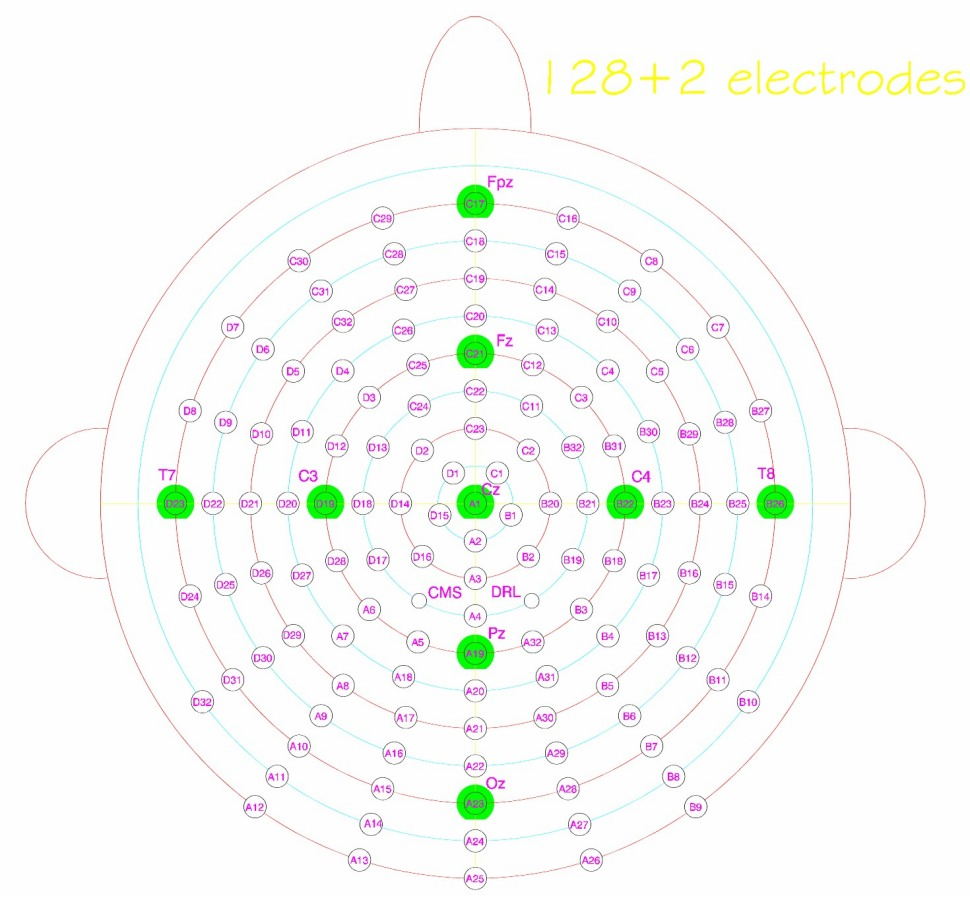

In [44]:
from IPython.display import Image, display

display(Image(filename='./images/cap_128_layout_medium.jpg', width=1100))

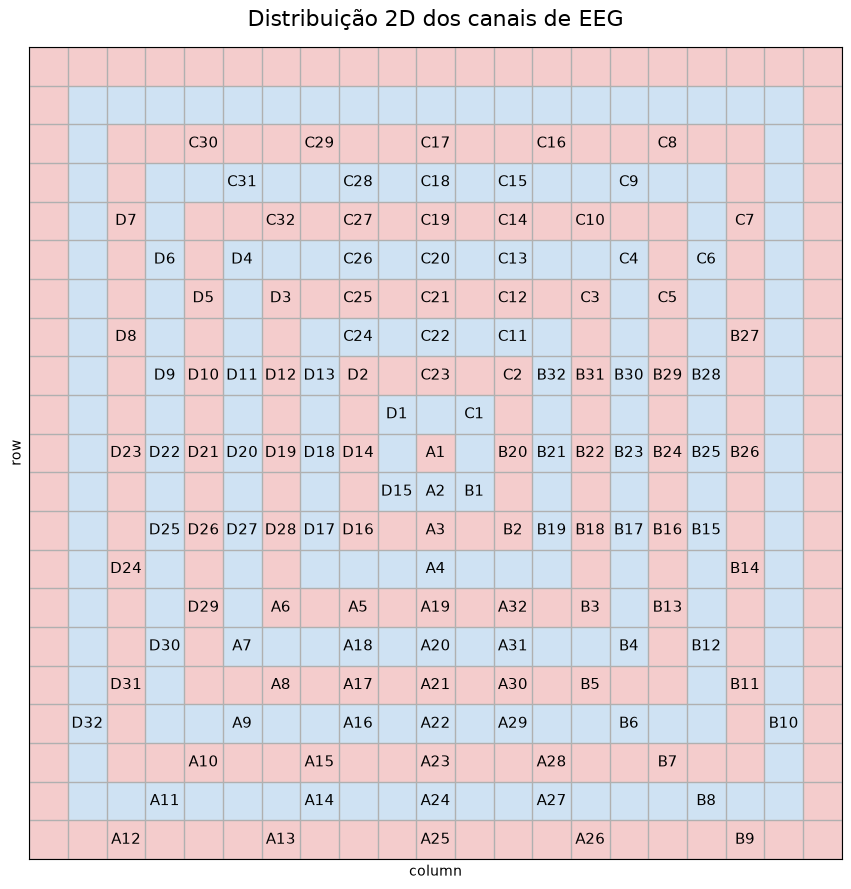

In [45]:
plot_channel_distribution(
    channels_2D_distribution
)

In [46]:
epoch_files = sorted(INPUT_DIR.glob("*_inner_epochs.npy"))

print(f"Sessões encontradas: {len(epoch_files)}")
for path in epoch_files[:6]:
    print(" -", path.relative_to(PROJECT_ROOT))

Sessões encontradas: 30
 - processed_data/stage_20_load_and_epoching/sub-01_ses-01_inner_epochs.npy
 - processed_data/stage_20_load_and_epoching/sub-01_ses-02_inner_epochs.npy
 - processed_data/stage_20_load_and_epoching/sub-01_ses-03_inner_epochs.npy
 - processed_data/stage_20_load_and_epoching/sub-02_ses-01_inner_epochs.npy
 - processed_data/stage_20_load_and_epoching/sub-02_ses-02_inner_epochs.npy
 - processed_data/stage_20_load_and_epoching/sub-02_ses-03_inner_epochs.npy


In [47]:
def obtain_espectrogram(data):

    SAMPLING_RATE = 256

    # Janela de 0,5 segundo.
    WINDOW_DURATION = 0.5

    # Deslocamento de 0,25 segundo.
    STEP_DURATION = 0.25

    nperseg = int(WINDOW_DURATION * SAMPLING_RATE)
    step_samples = int(STEP_DURATION * SAMPLING_RATE)
    noverlap = nperseg - step_samples

    frequencies, times, spectrogram_data = spectrogram(
        data,
        fs=SAMPLING_RATE,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nperseg,
        detrend="constant",
        scaling="density",
        mode="psd",
        axis=-1
    )

    print("Frequências:", frequencies.shape)
    print("Tempos:", times.shape)
    print("Espectrogramas:", spectrogram_data.shape)

    return frequencies, times, spectrogram_data






In [48]:
def create_power_array(data):

    rows_quantity = 21
    columns_quantity = 21

    #spectrogram_data.shape [epoch, channel, frequency, time_window]
    frequencies, times, spectrogram_data = obtain_espectrogram(data)

    #power_array.shape = [epoch, row, column, frequency, time_window]
    power_array = np.zeros([data.shape[0], rows_quantity, columns_quantity, frequencies.shape[0], times.shape[0]])

    for channel, channel_index in CHANNELS_INDICES_MAPPING.items():

        row = channels_2D_distribution[channel]['row']
        column = channels_2D_distribution[channel]['column']

        print(row)
        print(column)

        power_array[ : , row, column, :, : ] = spectrogram_data[:, channel_index, :, : ]

    # #verificando 
    # for channel, channel_index in CHANNELS_INDICES_MAPPING.items():
    #     row = channels_2D_distribution[channel]["row"]
    #     column = channels_2D_distribution[channel]["column"]

    #     np.testing.assert_allclose(
    #         power_array[:, row, column, :, :],
    #         spectrogram_data[:, channel_index, :, :]
    #     )

    # print("Todos os canais foram posicionados corretamente.")

    return frequencies, times, power_array

In [49]:
frequencies = None
times = None

for data_path in epoch_files:
    session_name = data_path.name.replace("_inner_epochs.npy", "")
    labels_path = INPUT_DIR / f"{session_name}_inner_epochs_labels.npy"

    data = np.load(data_path)
    labels = np.load(labels_path)

    current_frequencies, current_times, power_array = create_power_array(data)

    if frequencies is None:
        frequencies = current_frequencies
        times = current_times

    if len(power_array) != len(labels):
        raise ValueError(f"Épocas e rótulos incompatíveis em {session_name}")

    np.save(OUTPUT_DIR / f"{session_name}_power.npy", power_array)
    np.save(OUTPUT_DIR / f"{session_name}_labels.npy", labels)

    print(f"{session_name}: {power_array.shape}")

# Salva apenas uma vez
np.save(OUTPUT_DIR / "frequencies.npy", frequencies)
np.save(OUTPUT_DIR / "times.npy", times)

print("Stage 30 finalizado.")

Frequências: (65,)
Tempos: (9,)
Espectrogramas: (40, 128, 65, 9)
10
10
11
10
12
10
13
10
14
8
14
6
15
5
16
6
17
5
18
4
19
3
20
2
20
6
19
7
18
7
17
8
16
8
15
8
14
10
15
10
16
10
17
10
18
10
19
10
20
10
20
14
19
13
18
13
17
12
16
12
15
12
14
12
11
11
12
12
14
14
15
15
16
14
17
15
18
16
19
17
20
18
17
19
16
18
15
17
14
16
13
18
12
17
12
16
12
15
12
14
12
13
10
12
10
13
10
14
10
15
10
16
10
17
10
18
7
18
8
17
8
16
8
15
8
14
8
13
9
11
8
12
6
14
5
15
6
16
5
17
4
18
2
16
3
15
4
14
7
12
6
12
5
12
4
12
3
12
2
13
2
10
3
10
4
10
5
10
6
10
7
10
8
10
7
8
6
8
5
8
4
8
3
8
2
7
2
4
3
5
4
6
9
9
8
8
6
6
5
5
6
4
5
3
4
2
7
2
8
3
8
4
8
5
8
6
8
7
10
8
11
9
12
8
12
7
10
7
10
6
10
5
10
4
10
3
10
2
13
2
12
3
12
4
12
5
12
6
14
4
15
3
16
2
17
1
sub-01_ses-01: (40, 21, 21, 65, 9)
Frequências: (65,)
Tempos: (9,)
Espectrogramas: (40, 128, 65, 9)
10
10
11
10
12
10
13
10
14
8
14
6
15
5
16
6
17
5
18
4
19
3
20
2
20
6
19
7
18
7
17
8
16
8
15
8
14
10
15
10
16
10
17
10
18
10
19
10
20
10
20
14
19
13
18
13
17
12
16
12
15
12
1

In [50]:
subjects = [f"sub-{i:02d}" for i in range(1, 11)]
sessions = [f"ses-{i:02d}" for i in range(1, 4)]


for subject in subjects:

    print(f"\n{subject}")

    results = {}
    power_sessions = []
    label_sessions = []

    for session in sessions:

        """___Abrindo o aquivo a ser processado___"""

        file_path = os.path.join(
            OUTPUT_DIR,
            f"{subject}_{session}_power.npy"
        )

        labels_path = os.path.join(
            OUTPUT_DIR,
            f"{subject}_{session}_labels.npy"
        )

        if not os.path.exists(file_path):
            print(f"Arquivo não encontrado: {file_path}")
            continue

        if not os.path.exists(labels_path):
            print(f"Rótulos não encontrado: {labels_path}")
            continue


        power = np.load(file_path)
        labels = np.load(labels_path)

        print(f"Shape dos dados da seção: {power.shape}  \nShape dos rótulos da seção: {labels.shape}")

        power_sessions.append(power)
        label_sessions.append(labels)

        
    # Unindo as 3 sessões do sujeito

    if len(power_sessions) != len(sessions):
        print(f"Pulando {subject}: sessões incompletas")
        continue

    subject_power = np.concatenate(power_sessions, axis=0)
    subject_labels = np.concatenate(label_sessions, axis=0)

    if subject_power.shape[0] != subject_labels.shape[0]:
        raise ValueError(
            f"{subject}: número de épocas diferente do número de rótulos"
        )
    
    print(f"\n{subject} \nShape dos dados: {subject_power.shape} \nShape dos rótulos: {subject_labels.shape}", )

    np.save(OUTPUT_DIR / f"{subject}_power.npy", subject_power)
    np.save(OUTPUT_DIR / f"{subject}_labels.npy", subject_labels)

    # save_path_power = os.path.join(
    #     OUTPUT_DIR,
    #     f"{subject}_power.npy"
    # )

    # save_path_labels = os.path.join(
    #     OUTPUT_DIR,
    #     f"{subject}_labels.pkl"
    # )

    # with open(save_path_power, "wb") as f:
    #     pickle.dump(subject_power, f)

    # with open(save_path_labels, "wb") as f:
    #     pickle.dump(subject_labels, f)


sub-01
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (20, 21, 21, 65, 9)  
Shape dos rótulos da seção: (20,)

sub-01 
Shape dos dados: (100, 21, 21, 65, 9) 
Shape dos rótulos: (100,)

sub-02
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)

sub-02 
Shape dos dados: (120, 21, 21, 65, 9) 
Shape dos rótulos: (120,)

sub-03
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (40, 21, 21, 65, 9)  
Shape dos rótulos da seção: (40,)
Shape dos dados da seção: (20, 21, 21, 65, 9)  
Shape dos rótulos da seção: (20,)

sub-03 
Shape dos dados: (100, 21, 21, 65, 9) 
Shape dos rótulos: (100,)

sub-04
Shape do